# EDA Analysis: Amazon Product Data

Exploratory analysis of Amazon product listings — examining price, ratings, reviews, purchases, discounts, best-seller and sponsored status, coupons, and delivery speed to understand what drives monthly purchase volume.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [2]:
df = pd.read_csv("amazon_cleaned.csv")
df.head()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,...,sustainability_badges,image_url,product_url,collected_at,variant_price_clean,Listed_price_clean,final_price,Rating_clean,Number_of_reviews_clean,bought_in_last_month_clean
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,...,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14,NaN,159.00,89.68,4.6,375.0,300.0
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,...,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14,NaN,15.99,9.99,4.3,2457.0,6000.0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,...,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14,NaN,349.00,314.00,4.6,3044.0,2000.0
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,...,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14,162.24,NaN,162.24,4.6,35882.0,10000.0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,...,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14,72.74,NaN,72.74,4.8,28988.0,10000.0


## 1. Price Analysis

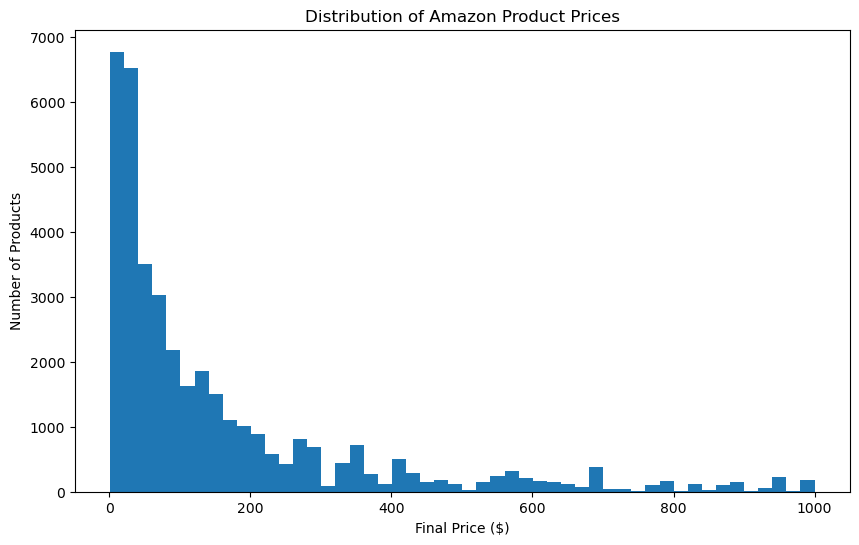

In [3]:
plt.figure(figsize=(10,6))
plt.hist(df['final_price'].dropna(), bins=50)
plt.xlabel('Final Price ($)')
plt.ylabel('Number of Products')
plt.title('Distribution of Amazon Product Prices')
plt.show()

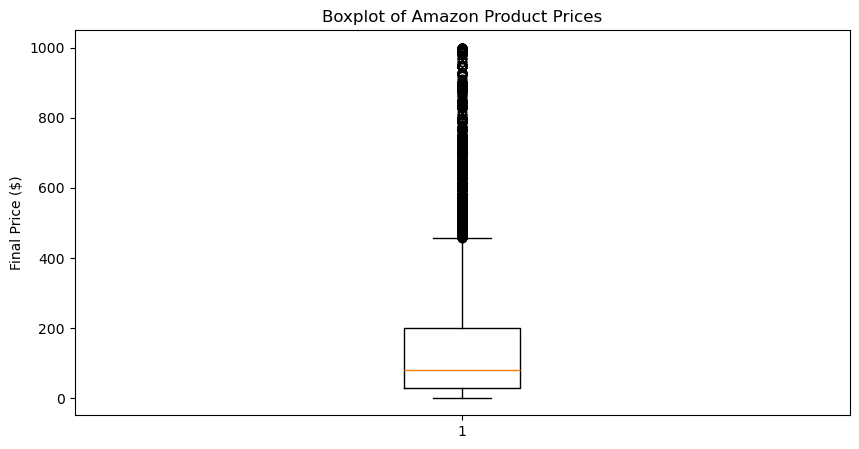

In [4]:
plt.figure(figsize=(10, 5))
plt.boxplot(df["final_price"].dropna())
plt.ylabel("Final Price ($)")
plt.title("Boxplot of Amazon Product Prices")
plt.show()

## 2. Rating Analysis

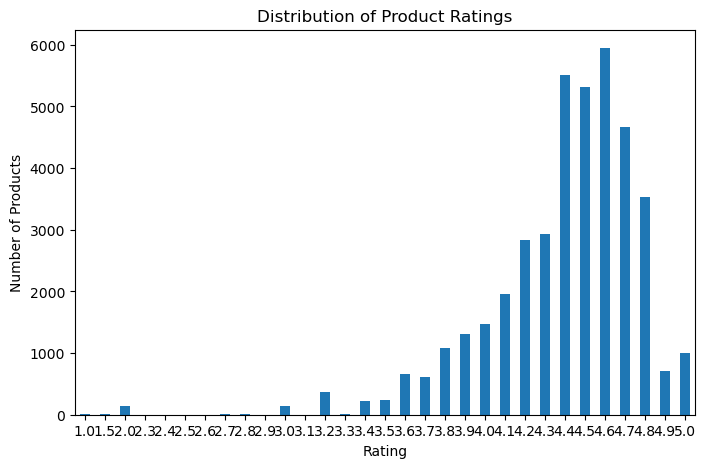

In [5]:
plt.figure(figsize=(8,5))
df["Rating_clean"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Ratings")
plt.xticks(rotation=0)
plt.show()

The rating distribution is generally positive. The average rating is approximately 4.4 out of 5, and about 88.12% of products with valid ratings have ratings of 4 stars or higher. Only 11.88% have ratings below 4 stars.

## 3. Reviews Analysis

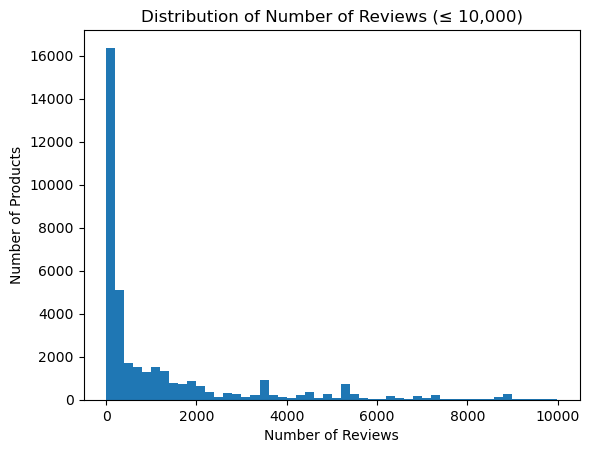

In [6]:
df[df["Number_of_reviews_clean"] <= 10000]["Number_of_reviews_clean"].plot(
    kind="hist",
    bins=50
)
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Products")
plt.title("Distribution of Number of Reviews (≤ 10,000)")
plt.show()

## 4. Monthly Purchases Analysis

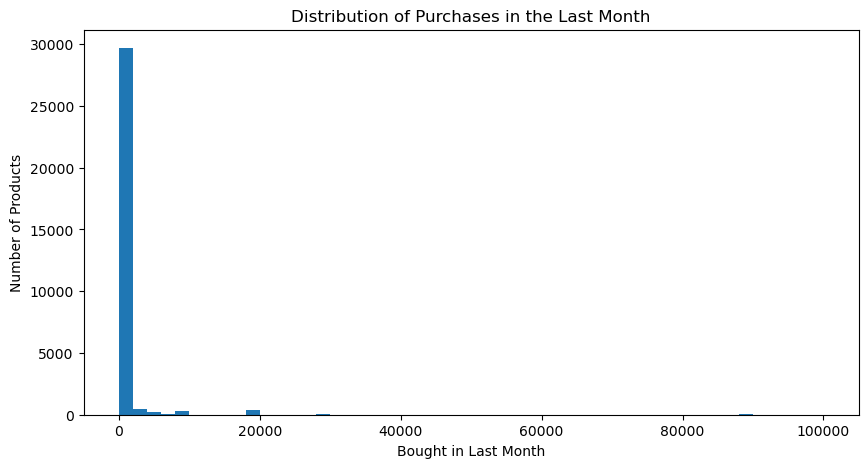

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(df["bought_in_last_month_clean"].dropna(), bins=50)
plt.xlabel("Bought in Last Month")
plt.ylabel("Number of Products")
plt.title("Distribution of Purchases in the Last Month")
plt.show()

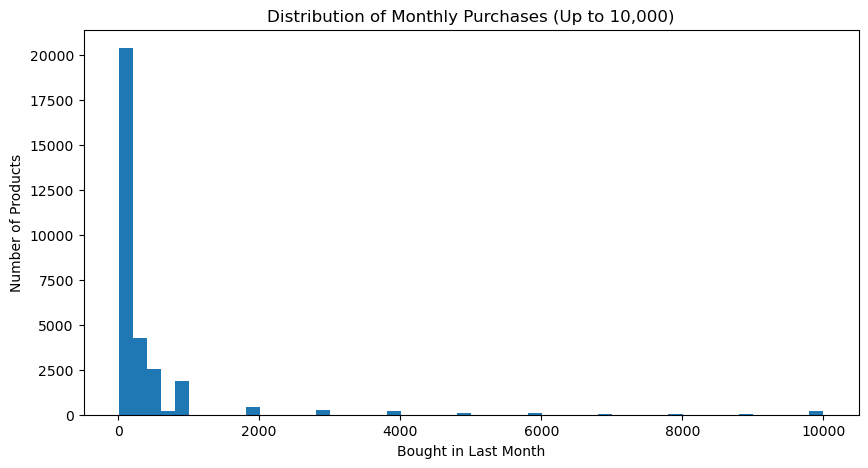

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(
    df.loc[df["bought_in_last_month_clean"] <= 10000,
           "bought_in_last_month_clean"].dropna(),
    bins=50
)
plt.xlabel("Bought in Last Month")
plt.ylabel("Number of Products")
plt.title("Distribution of Monthly Purchases (Up to 10,000)")
plt.show()

The distribution of monthly purchases is highly right-skewed. Most products have relatively low purchase counts, while a small number of products show exceptionally high purchase volumes. The median monthly purchase count is 200, compared with a mean of approximately 945, indicating that a few highly popular products significantly increase the average.

### 4.1 Rating vs Monthly Purchases

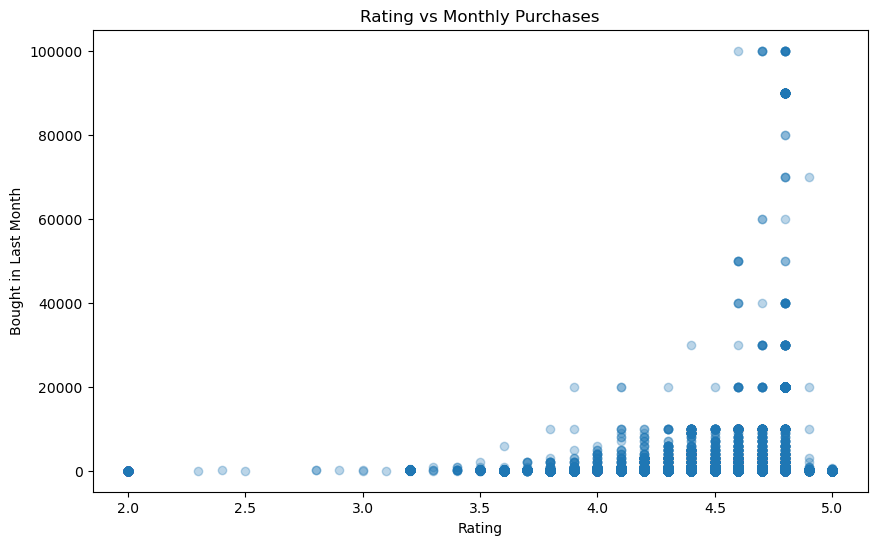

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Rating_clean"],
    df["bought_in_last_month_clean"],
    alpha=0.3
)
plt.xlabel("Rating")
plt.ylabel("Bought in Last Month")
plt.title("Rating vs Monthly Purchases")
plt.show()

In [10]:
df[["Rating_clean", "bought_in_last_month_clean"]].corr()

,Rating_clean,bought_in_last_month_clean
Rating_clean,1.000000,0.124985
bought_in_last_month_clean,0.124985,1.000000


The data shows a slight positive relationship between product rating and monthly purchases. However, the correlation is weak (0.125), suggesting that rating alone is not a strong predictor of sales. Some highly rated products, such as those around 4.8 stars, have very high purchases, but high ratings do not consistently lead to high purchases.

### 4.2 Reviews vs Monthly Purchases

Do products with more customer reviews also tend to have more monthly purchases?

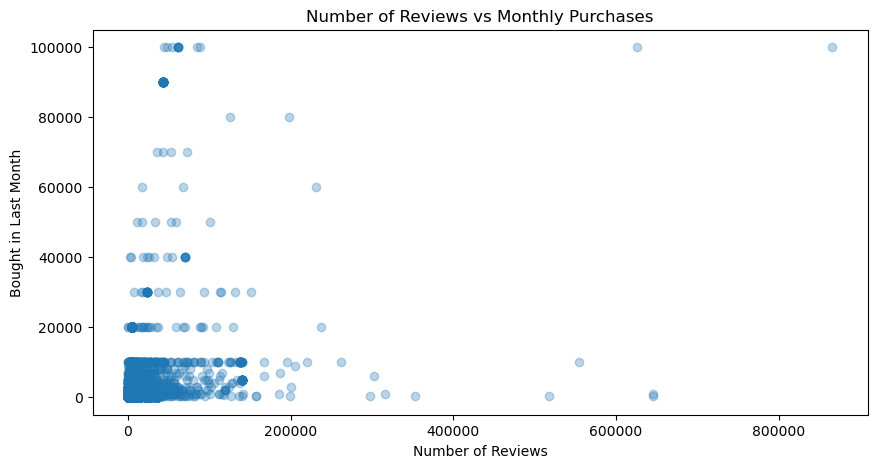

In [11]:
plt.figure(figsize=(10, 5))
plt.scatter(
    df["Number_of_reviews_clean"],
    df["bought_in_last_month_clean"],
    alpha=0.3
)
plt.xlabel("Number of Reviews")
plt.ylabel("Bought in Last Month")
plt.title("Number of Reviews vs Monthly Purchases")
plt.show()

In [12]:
df[["Number_of_reviews_clean", "bought_in_last_month_clean"]].corr()

,Number_of_reviews_clean,bought_in_last_month_clean
Number_of_reviews_clean,1.000000,0.304411
bought_in_last_month_clean,0.304411,1.000000


Customer reviews appear to be more strongly associated with monthly purchases than product ratings. The correlation between reviews and purchases is 0.304, compared with only 0.125 for ratings.

### 4.3 Discount vs Monthly Purchases

Do discounted products tend to have higher monthly purchases?

In [13]:
df["discount_percentage"] = (
    (df["Listed_price_clean"] - df["final_price"])
    / df["Listed_price_clean"]
) * 100

In [14]:
df["discount_percentage_clean"] = df["discount_percentage"].where(
    (df["discount_percentage"] >= 0) &
    (df["discount_percentage"] <= 100)
)

In [15]:
bins = [0, 10, 20, 30, 40, 100]
labels = ["0–10%", "10–20%", "20–30%", "30–40%", "40%+"]

df["discount_range"] = pd.cut(
    df["discount_percentage_clean"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [16]:
discount_purchase = (
    df.groupby("discount_range", observed=True)["bought_in_last_month_clean"]
      .mean()
      .reset_index()
)

discount_purchase

,discount_range,bought_in_last_month_clean
0,0–10%,406.716418
1,10–20%,3037.113104
2,20–30%,888.335810
3,30–40%,859.096652
4,40%+,1451.418440


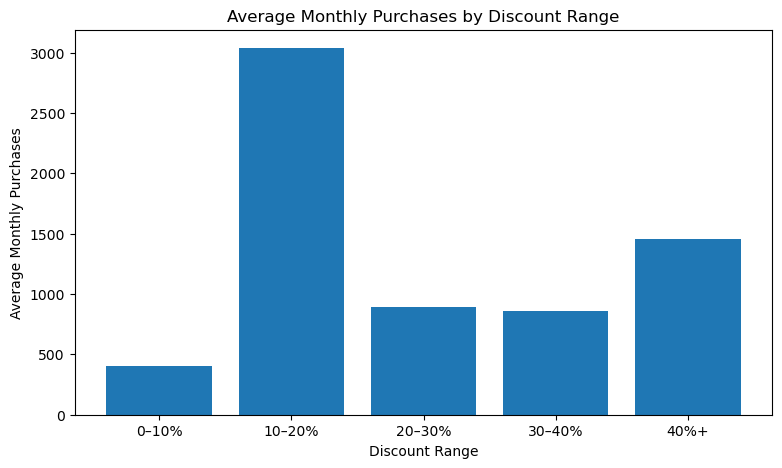

In [17]:
plt.figure(figsize=(9, 5))

plt.bar(
    discount_purchase["discount_range"].astype(str),
    discount_purchase["bought_in_last_month_clean"]
)

plt.xlabel("Discount Range")
plt.ylabel("Average Monthly Purchases")
plt.title("Average Monthly Purchases by Discount Range")

plt.show()

Products with a 10–20% discount had the highest average monthly purchases. Higher discounts did not consistently result in higher purchases, suggesting that moderate discounts may be associated with stronger sales performance.

## 5. Best Seller Analysis

In [18]:
df["best_seller_status"] = df["is_best_seller"].astype(str).str.contains(
    "Best Seller", case=False, na=False
).map({True: "Best Seller", False: "Not Best Seller"})

df["best_seller_status"].value_counts()

best_seller_status
Not Best Seller    41438
Best Seller          275
Name: count, dtype: int64

In [19]:
best_seller_purchases = (
    df.groupby("best_seller_status")["bought_in_last_month_clean"]
      .mean()
      .sort_values(ascending=False)
)

best_seller_purchases

best_seller_status
Best Seller        9228.624535
Not Best Seller     872.802095
Name: bought_in_last_month_clean, dtype: float64

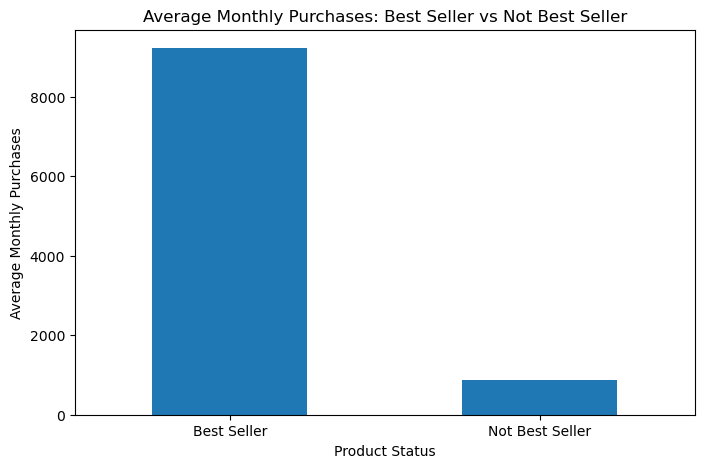

In [20]:
plt.figure(figsize=(8,5))
best_seller_purchases.plot(kind="bar")
plt.title("Average Monthly Purchases: Best Seller vs Not Best Seller")
plt.xlabel("Product Status")
plt.ylabel("Average Monthly Purchases")
plt.xticks(rotation=0)
plt.show()

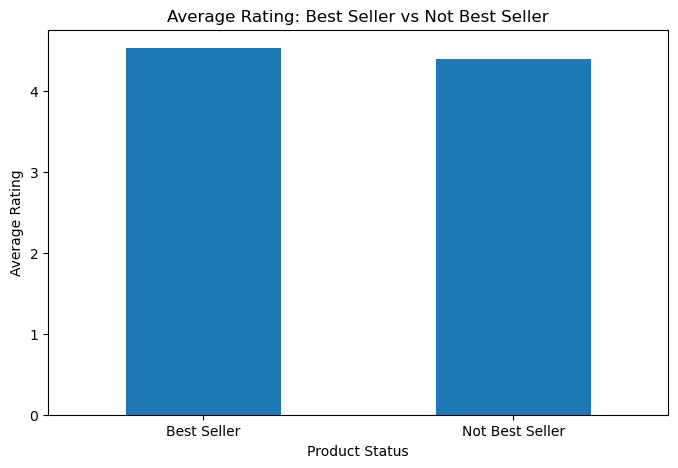

In [21]:
plt.figure(figsize=(8,5))
df.groupby("best_seller_status")["Rating_clean"].mean().plot(kind="bar")
plt.title("Average Rating: Best Seller vs Not Best Seller")
plt.xlabel("Product Status")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

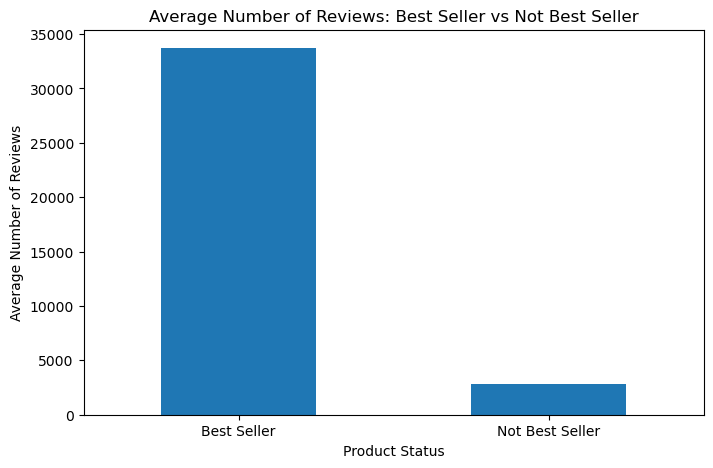

In [22]:
plt.figure(figsize=(8,5))
df.groupby("best_seller_status")["Number_of_reviews_clean"].mean().plot(kind="bar")
plt.title("Average Number of Reviews: Best Seller vs Not Best Seller")
plt.xlabel("Product Status")
plt.ylabel("Average Number of Reviews")
plt.xticks(rotation=0)
plt.show()

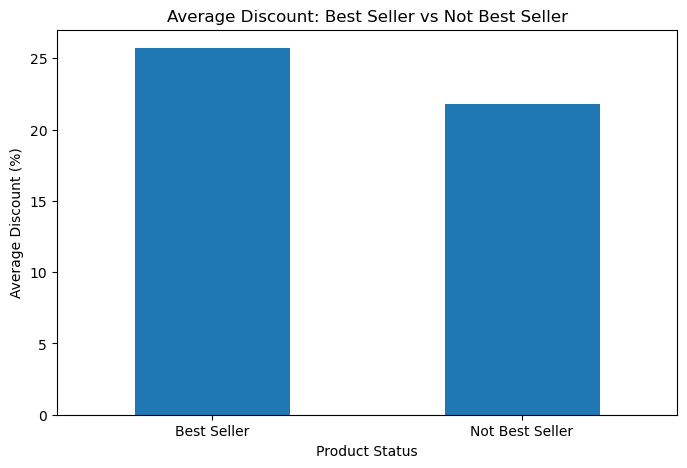

In [23]:
plt.figure(figsize=(8,5))
df.groupby("best_seller_status")["discount_percentage_clean"].mean().plot(kind="bar")
plt.title("Average Discount: Best Seller vs Not Best Seller")
plt.xlabel("Product Status")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=0)
plt.show()

Best Seller status appears to be more strongly associated with product popularity and customer engagement—particularly monthly purchases and review volume—than with rating alone. Discounts show a smaller difference between the two groups.

## 6. Sponsored Product Analysis

### Sponsored vs Monthly Purchases

In [24]:
df.groupby("is_sponsored")["bought_in_last_month_clean"].mean()

is_sponsored
Organic       486.369769
Sponsored    5439.819945
Name: bought_in_last_month_clean, dtype: float64

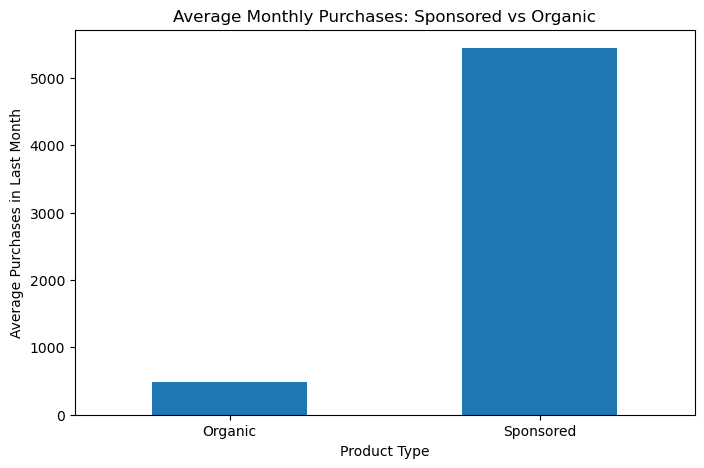

In [25]:
sponsored_purchases = df.groupby("is_sponsored")["bought_in_last_month_clean"].mean()

sponsored_purchases.plot(kind="bar", figsize=(8,5))
plt.xlabel("Product Type")
plt.ylabel("Average Purchases in Last Month")
plt.title("Average Monthly Purchases: Sponsored vs Organic")
plt.xticks(rotation=0)
plt.show()

Sponsored products have significantly higher average monthly purchases than organic products. Sponsored products average approximately 5,440 purchases per month, compared with approximately 486 for organic products.

### Sponsored vs Rating

In [26]:
df.groupby("is_sponsored")["Rating_clean"].mean()

is_sponsored
Organic      4.394149
Sponsored    4.375231
Name: Rating_clean, dtype: float64

So higher purchases aren't simply explained by having a higher average rating.

### Sponsored vs Reviews

Do sponsored products have more customer reviews than organic products?

In [27]:
df.groupby("is_sponsored")["Number_of_reviews_clean"].mean()

is_sponsored
Organic      2933.277627
Sponsored    3706.349891
Name: Number_of_reviews_clean, dtype: float64

Sponsored products have substantially higher average monthly purchases and more reviews than organic products, while their average rating is slightly lower.

### Sponsored vs Best Seller Share

What percentage of sponsored and organic products are best sellers?

In [28]:
df.groupby("is_sponsored")["is_best_seller"].value_counts(normalize=True) * 100

is_sponsored  is_best_seller   
Organic       No Badge             96.284270
              Amazon's              1.417398
              Best Seller           0.621171
              Limited time deal     0.573171
              Save 30%              0.352938
              Ends in               0.273880
              Save 10%              0.172234
              Save 18%              0.160940
              Save 17%              0.143999
Sponsored     No Badge             92.296696
              Amazon's              3.668996
              Limited time deal     2.493647
              Best Seller           0.873571
              Save 12%              0.412961
              Save 9%               0.222363
              Save 77%              0.031766
Name: proportion, dtype: float64

Sponsored products make up a smaller share of the dataset but show substantially higher average monthly purchases and reviews. Their average rating is almost identical to organic products, while the Best Seller badge appears slightly more frequently among sponsored products.

## 7. Coupon Analysis

In [29]:
df["coupon_status"] = df["is_couponed"].apply(
    lambda x: "No Coupon" if x == "No Coupon" else "Coupon"
)

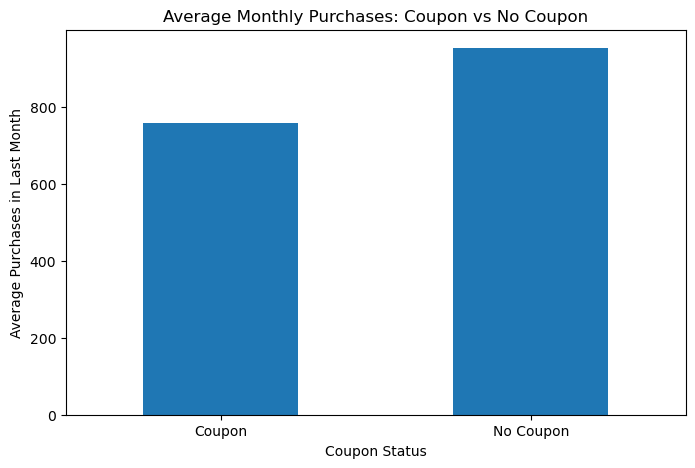

In [30]:
coupon_purchases = df.groupby("coupon_status")["bought_in_last_month_clean"].mean()

coupon_purchases.plot(kind="bar", figsize=(8,5))
plt.xlabel("Coupon Status")
plt.ylabel("Average Purchases in Last Month")
plt.title("Average Monthly Purchases: Coupon vs No Coupon")
plt.xticks(rotation=0)
plt.show()

Products without coupons recorded higher average monthly purchases (952) compared with couponed products (757). This suggests that the presence of a coupon was not associated with higher monthly purchases in this dataset.

## 8. Buy Box Analysis

Do products with Buy Box availability have higher monthly purchases?

In [31]:
df["buy_box_availability"].value_counts()

buy_box_availability
Add to cart    27221
Name: count, dtype: int64

The buy_box_availability column contains only the value 'Add to cart' for 27,221 products. Since there is no variation in Buy Box status, a comparison between Buy Box-available and unavailable products cannot be performed using this dataset.

## 9. Delivery Analysis

Does delivery information appear to be associated with monthly purchases?

In [32]:
df["delivery_details"].value_counts().head(20)

delivery_details
Delivery Mon, Sep 1                                                                               5903
Delivery Thu, Sep 4                                                                               4161
Delivery Thu, Sep 11                                                                              3648
Delivery Tue, Sep 2                                                                               3170
Delivery Wed, Sep 3                                                                               2143
Delivery Tue, Sep 9                                                                               1165
FREE delivery Wed, Sep 3Or fastest delivery Sun, Aug 31                                           1012
FREE delivery Thu, Sep 4Or fastest delivery Tomorrow, Aug 31                                      1003
FREE delivery Wed, Sep 3 on $35 of items shipped by AmazonOr fastest delivery Sun, Aug 31          725
FREE delivery Thu, Sep 4 on $35 of items shipped by Amaz

In [33]:
df["collected_at"] = pd.to_datetime(
    df["collected_at"],
    format="%d-%m-%Y %H:%M"
)
df["collected_at"].head()

0   2025-08-21 11:14:00
1   2025-08-21 11:14:00
2   2025-08-21 11:14:00
3   2025-08-21 11:14:00
4   2025-08-21 11:14:00
Name: collected_at, dtype: datetime64[ns]

In [34]:
df["delivery_date_text"] = df["delivery_details"].str.extract(
    r"((?:Aug|Sep)\s+\d{1,2})"
)
df["delivery_date"] = pd.to_datetime(
    df["delivery_date_text"] + " 2025",
    format="%b %d %Y",
    errors="coerce"
)

In [35]:
df[["delivery_details", "delivery_date"]].head(10)

,delivery_details,delivery_date
0,"Delivery Mon, Sep 1",2025-09-01
1,"Delivery Fri, Aug 29",2025-08-29
2,"Delivery Mon, Sep 1",2025-09-01
3,NaN,NaT
4,NaN,NaT
5,NaN,NaT
6,NaN,NaT
7,NaN,NaT
8,NaN,NaT
9,NaN,NaT


In [36]:
df["delivery_days"] = (
    df["delivery_date"] - df["collected_at"]
).dt.days

df[["collected_at", "delivery_date", "delivery_days"]].head(10)

,collected_at,delivery_date,delivery_days
0,2025-08-21 11:14:00,2025-09-01,10.0
1,2025-08-21 11:14:00,2025-08-29,7.0
2,2025-08-21 11:14:00,2025-09-01,10.0
3,2025-08-21 11:14:00,NaT,NaN
4,2025-08-21 11:14:00,NaT,NaN
5,2025-08-21 11:14:00,NaT,NaN
6,2025-08-21 11:14:00,NaT,NaN
7,2025-08-21 11:14:00,NaT,NaN
8,2025-08-21 11:14:00,NaT,NaN
9,2025-08-21 11:14:00,NaT,NaN


In [37]:
df["delivery_speed"] = pd.cut(
    df["delivery_days"],
    bins=[0, 3, 7, 14, float("inf")],
    labels=["1–3 days", "4–7 days", "8–14 days", "15+ days"]
)

In [38]:
df.groupby(
    "delivery_speed",
    observed=True
)["bought_in_last_month_clean"].mean()

delivery_speed
1–3 days       57.231405
4–7 days     1272.444367
8–14 days    1018.364229
15+ days      157.253669
Name: bought_in_last_month_clean, dtype: float64

In [39]:
df.groupby(
    "delivery_speed",
    observed=True
)["bought_in_last_month_clean"].median()

delivery_speed
1–3 days      50.0
4–7 days     200.0
8–14 days    200.0
15+ days     100.0
Name: bought_in_last_month_clean, dtype: float64

Products with 4–7 day delivery have the highest average monthly purchases, but the median is only 200. This indicates that a small number of highly popular products may be driving the high average. Overall, delivery speed does not show a clear linear relationship with monthly purchases.

## Key Findings

- Rating alone is a weak predictor of monthly purchases (corr ≈ 0.125); review count is a stronger signal (corr ≈ 0.304).
- Best Seller status and Sponsored status are both strongly associated with higher monthly purchases and review volume.
- Moderate discounts (10–20%) are associated with the highest average purchases — deeper discounts don't consistently perform better.
- Coupons were not associated with higher purchases in this dataset.
- Buy Box availability couldn't be evaluated — no variation in the column.
- Delivery speed shows no clear linear relationship with purchase volume; the 4–7 day group's high average appears driven by a few outlier products (mean vs median gap).